## Major Data Analytics Project

Domain: Agriculture

Project Theme: Seasonal Agriculture Performance

Tools:Python, Pandas, NumPy, Matplotlib, Seaborn



**Project Goal**
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, 
farming practices, resource availability and market conditions. As a result, agricultural 
performance may differ from one season to another. 
However, raw agricultural data does not clearly explain how agricultural performance changes 
across seasons or what patterns can be observed in different seasonal conditions. 
The problem is to analyze the given agricultural dataset and investigate seasonal differences 
in agricultural performance by identifying meaningful patterns, trends, relationships and 
variations within the available data.

## Project Objective

1.Understand the structure and quality of the agricultural dataset.

2.Clean and prepare the data for analysis.

3.Explore seasonal patterns in the dataset.

4.Perform descriptive and statistical analysis.

5.Investigate relationships among relevant variables.

6.Compare agricultural performance across seasons and other meaningful groups.

7.Use appropriate univariate, bivariate and multivariate visualizations.

8.Identify significant findings from the data.

9.Develop evidence-based insights and recommendations.

## Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental

practices, production, costs, revenue, profit and resource usage.

**Dataset file**: seasonal_agriculture_performance_dataset.csv

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [4]:
# 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully")

Libraries imported successfully


In [10]:
# 2 — Load dataset
from pathlib import Path
file_path = Path("seasonal_agriculture_performance_dataset.csv")

if not file_path.exists():
    csv_files = list(Path(".").glob("*.csv"))
    if csv_files:
        file_path = csv_files[0]
    else:
        raise FileNotFoundError(
            "CSV file not found. Put seasonal_agriculture_performance_dataset.csv "
            "in the same folder as the notebook."
        )

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print(f"File: {file_path.name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully
File: seasonal_agriculture_performance_dataset.csv
Rows: 4,000
Columns: 28


In [12]:
#3 — Top 5 rows analyzed
print("Top 5 rows analyzed")
display(df.head())

Top 5 rows analyzed


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [13]:
#4 — Dataset shape and structure examined
print("Dataset shape and structure examined")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nDataset info:")
df.info()

Dataset shape and structure examined
Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3  

In [14]:
#5 — Data types examined
print("Data types examined")
display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notna().sum().values,
    "Unique_Values": df.nunique().values
}))

Data types examined


,Column,Data_Type,Non_Null_Count,Unique_Values
0,Farm_ID,object,4000,4000
1,State,object,4000,8
2,District,object,4000,10
3,Crop,object,4000,8
4,Season,object,4000,3
5,Farm_Area_Hectares,float64,4000,1370
6,Rainfall_mm,float64,3952,3256
7,Avg_Temperature_C,float64,4000,204
8,Humidity_pct,float64,4000,573
9,Sunlight_Hours_Day,float64,4000,71


In [18]:
#6 — Missing values identified and handled
print("Missing values BEFORE handling:")
missing_before = df.isna().sum()
display(missing_before[missing_before > 0].to_frame("Missing_Count"))

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Fill numeric missing values with median
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isna().any():
        mode_value = df[col].mode(dropna=True)
        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value.iloc[0])
        else:
            df[col] = df[col].fillna("Unknown")

missing_after = df.isna().sum()

print("\nMissing values AFTER handling:")
display(missing_after[missing_after > 0].to_frame("Remaining_Missing_Count"))

if missing_after.sum() == 0:
    print("All missing values handled successfully.")

Missing values BEFORE handling:


,Missing_Count



Missing values AFTER handling:


,Remaining_Missing_Count


All missing values handled successfully.


In [19]:
#7 — Duplicate records identified and handled
duplicate_count = df.duplicated().sum()
print(f"Duplicate records identified: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows after duplicate handling: {len(df):,}")
print(f"Remaining duplicate records: {df.duplicated().sum()}")
print("Duplicate records identified and handled")

Duplicate records identified: 0
Rows after duplicate handling: 4,000
Remaining duplicate records: 0
Duplicate records identified and handled


In [20]:
#8 — Descriptive/statistical analysis performed
print("Descriptive/statistical analysis performed")

print("Numeric descriptive statistics:")
display(df[numeric_cols].describe().T)

print("\nCategorical summary:")
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    display(df[col].value_counts().head(10).to_frame("Count"))

Descriptive/statistical analysis performed
Numeric descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00



Categorical summary:

Farm_ID: 4000 unique values


,Count
Farm_ID,
SF10001,1
SF12672,1
SF12659,1
SF12660,1
SF12661,1
SF12662,1
SF12663,1
SF12664,1
SF12665,1



State: 8 unique values


...

,Count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



Season: 3 unique values


,Count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Irrigation_Method: 4 unique values


,Count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


Outliers investigated


,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
18,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302,7.55
19,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"207,517.25","836,874.75","-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,86.20,123.60,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,6.60,8.10,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,46.20,69.40,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,143.97,227.20,19.14,352.04,15,0.38


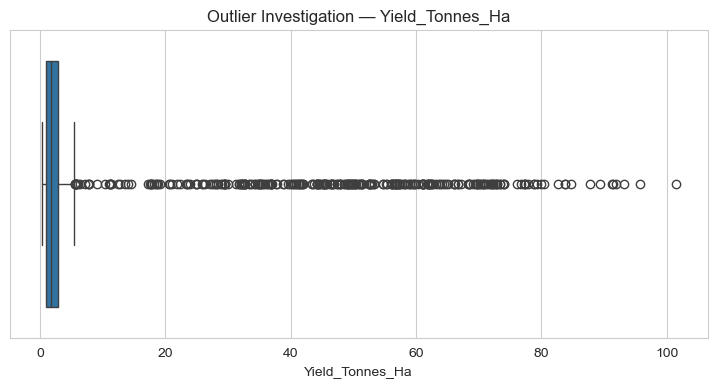

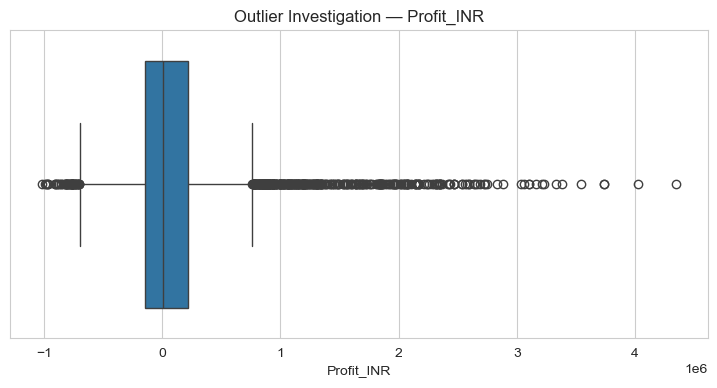

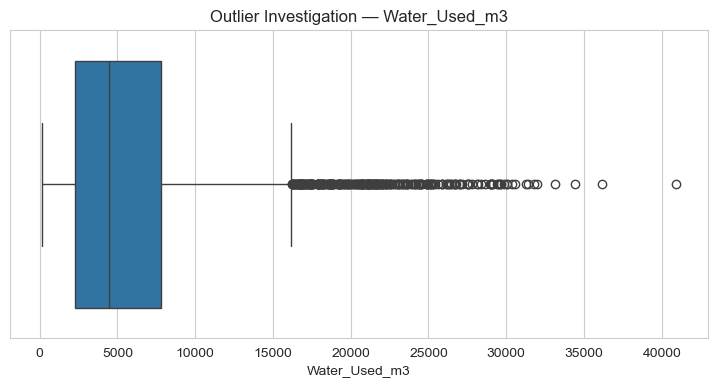

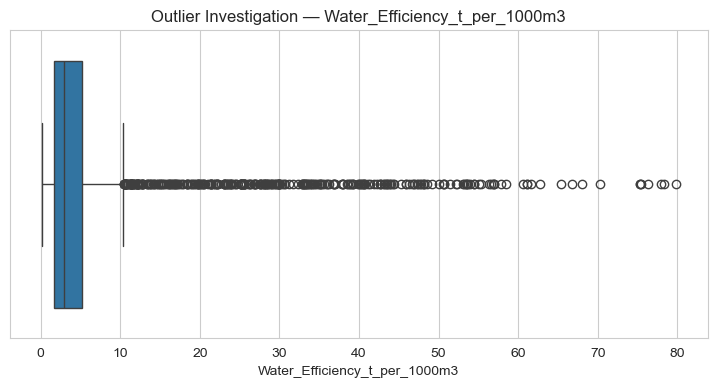

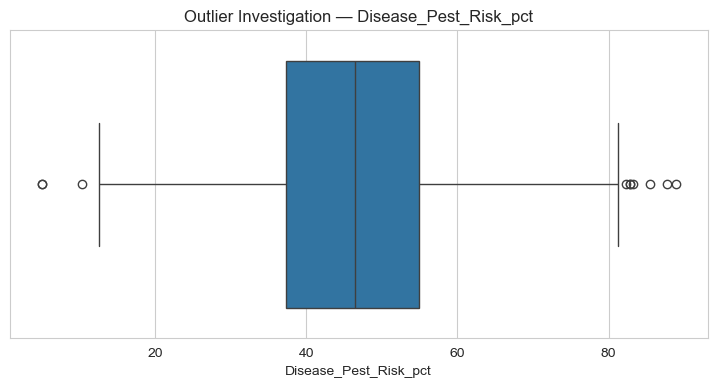

Outliers are investigated rather than automatically deleted because extreme agricultural observations may represent genuine farms or conditions.


In [21]:
#9 — Outliers investigated using IQR
print("Outliers investigated")

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, count, count / len(df) * 100])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Variable", "Q1", "Q3", "Lower_Bound", "Upper_Bound", "Outlier_Count", "Outlier_Percent"]
).sort_values("Outlier_Count", ascending=False)

display(outlier_df)

# Visual investigation of key performance variables
key_outlier_cols = [
    "Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]
for col in key_outlier_cols:
    if col in df.columns:
        plt.figure(figsize=(9, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Outlier Investigation — {col}")
        plt.xlabel(col)
        plt.show()

print("Outliers are investigated rather than automatically deleted because extreme agricultural observations may represent genuine farms or conditions.")

Univariate analysis completed


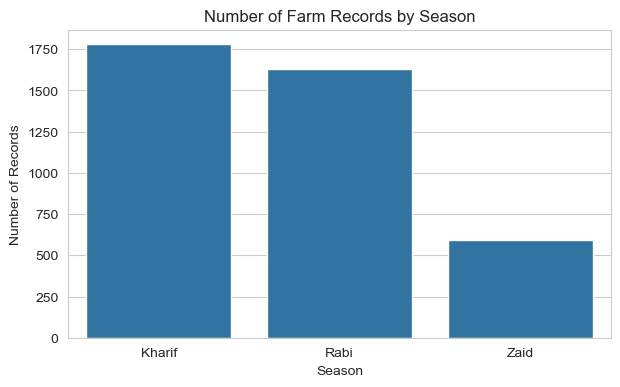

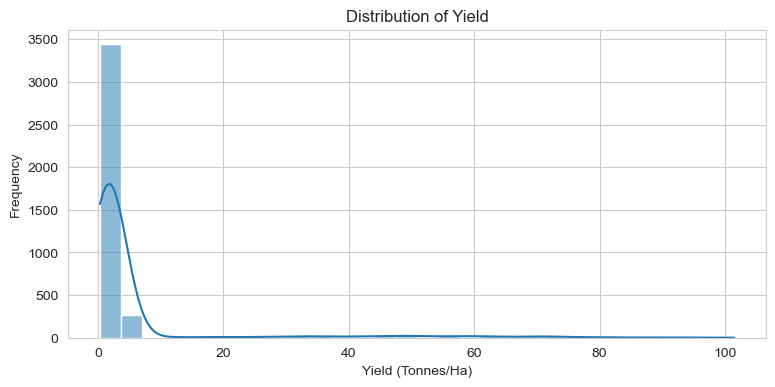

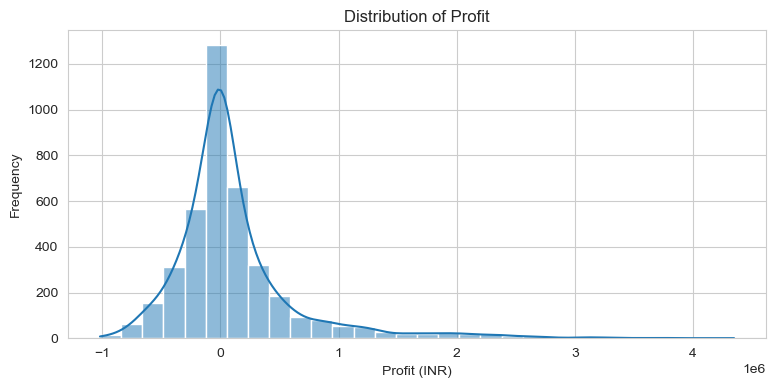

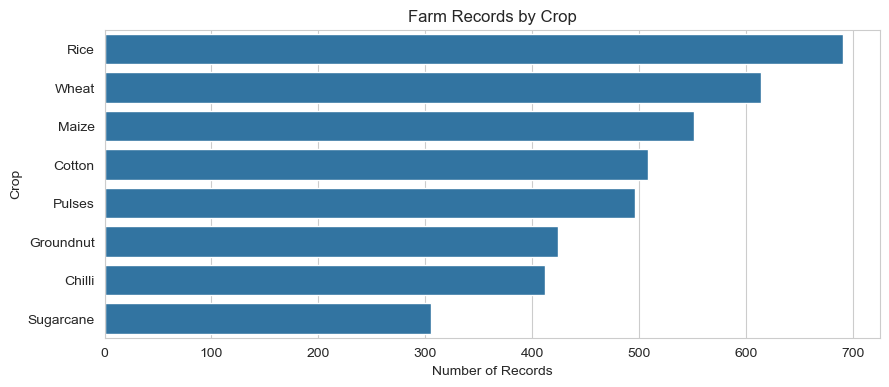

In [22]:
#10 — Univariate analysis completed
print("Univariate analysis completed")

# Season distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Season", order=df["Season"].value_counts().index)
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

# Yield distribution
plt.figure(figsize=(9, 4))
sns.histplot(df["Yield_Tonnes_Ha"], bins=30, kde=True)
plt.title("Distribution of Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.show()

# Profit distribution
plt.figure(figsize=(9, 4))
sns.histplot(df["Profit_INR"], bins=30, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.show()

# Crop distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index)
plt.title("Farm Records by Crop")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

Bivariate analysis completed


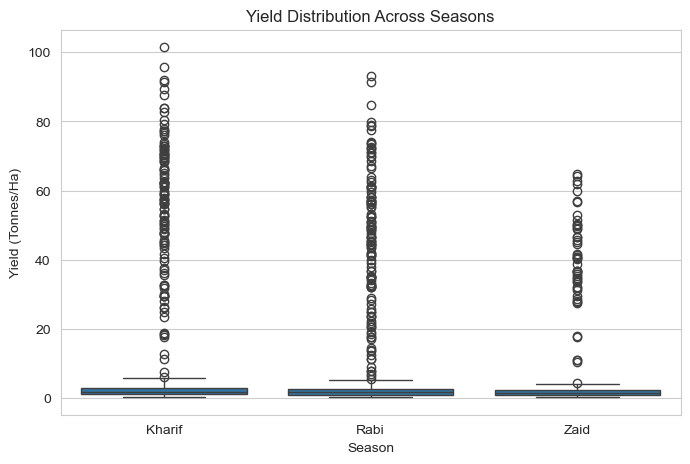

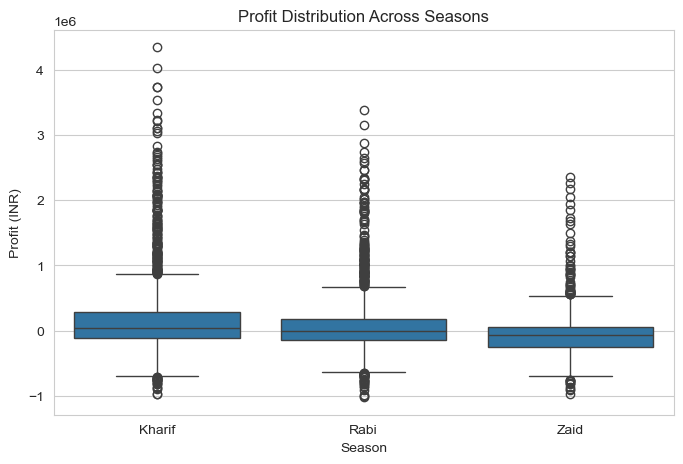

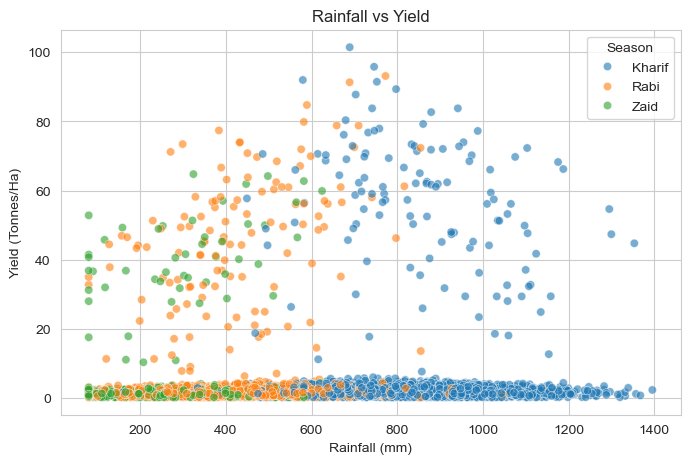

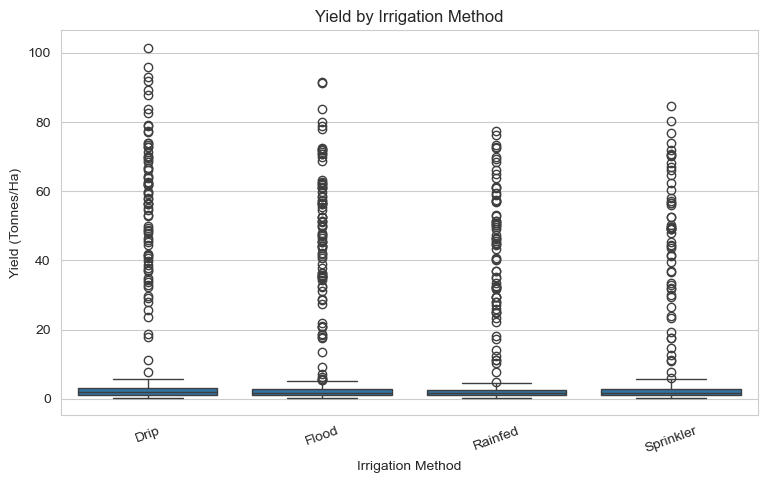

In [23]:
#11 — Bivariate analysis completed
print("Bivariate analysis completed")

# Season vs Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

# Season vs Profit
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

# Rainfall vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

# Irrigation method vs yield
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha")
plt.title("Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=20)
plt.show()

Multivariate analysis completed


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


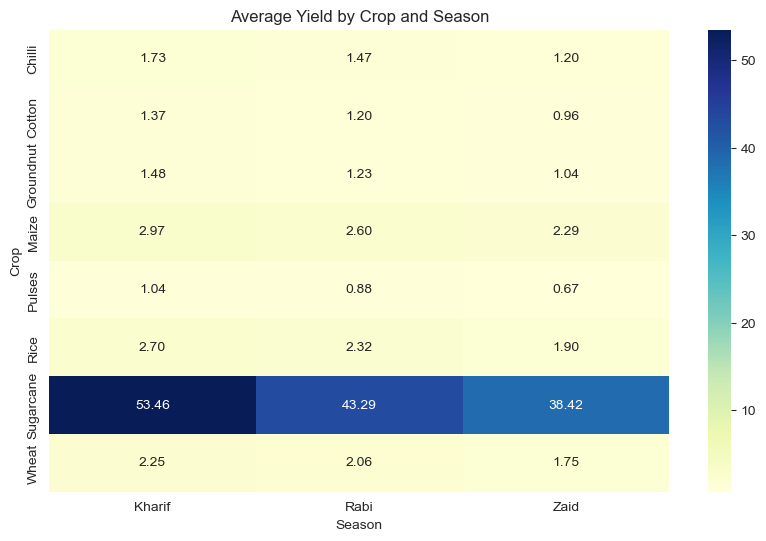

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.11,5.85
Flood,4.98,5.06,3.98
Rainfed,5.70,3.93,3.06
Sprinkler,4.66,5.31,6.14


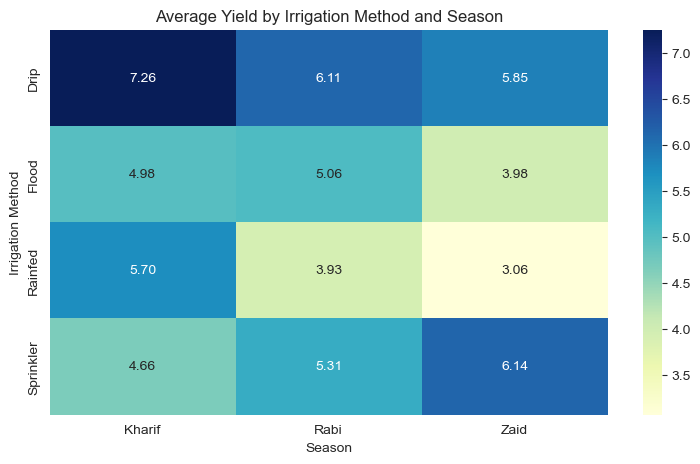

In [24]:
#12 — Multivariate analysis completed
print("Multivariate analysis completed")

# Season × Crop average yield
season_crop_yield = pd.pivot_table(
    df, index="Crop", columns="Season",
    values="Yield_Tonnes_Ha", aggfunc="mean"
)

display(season_crop_yield.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(season_crop_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

# Season × Irrigation average yield
season_irrigation_yield = pd.pivot_table(
    df, index="Irrigation_Method", columns="Season",
    values="Yield_Tonnes_Ha", aggfunc="mean"
)

display(season_irrigation_yield.round(2))

plt.figure(figsize=(9, 5))
sns.heatmap(season_irrigation_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")
plt.show()

Correlation analysis completed


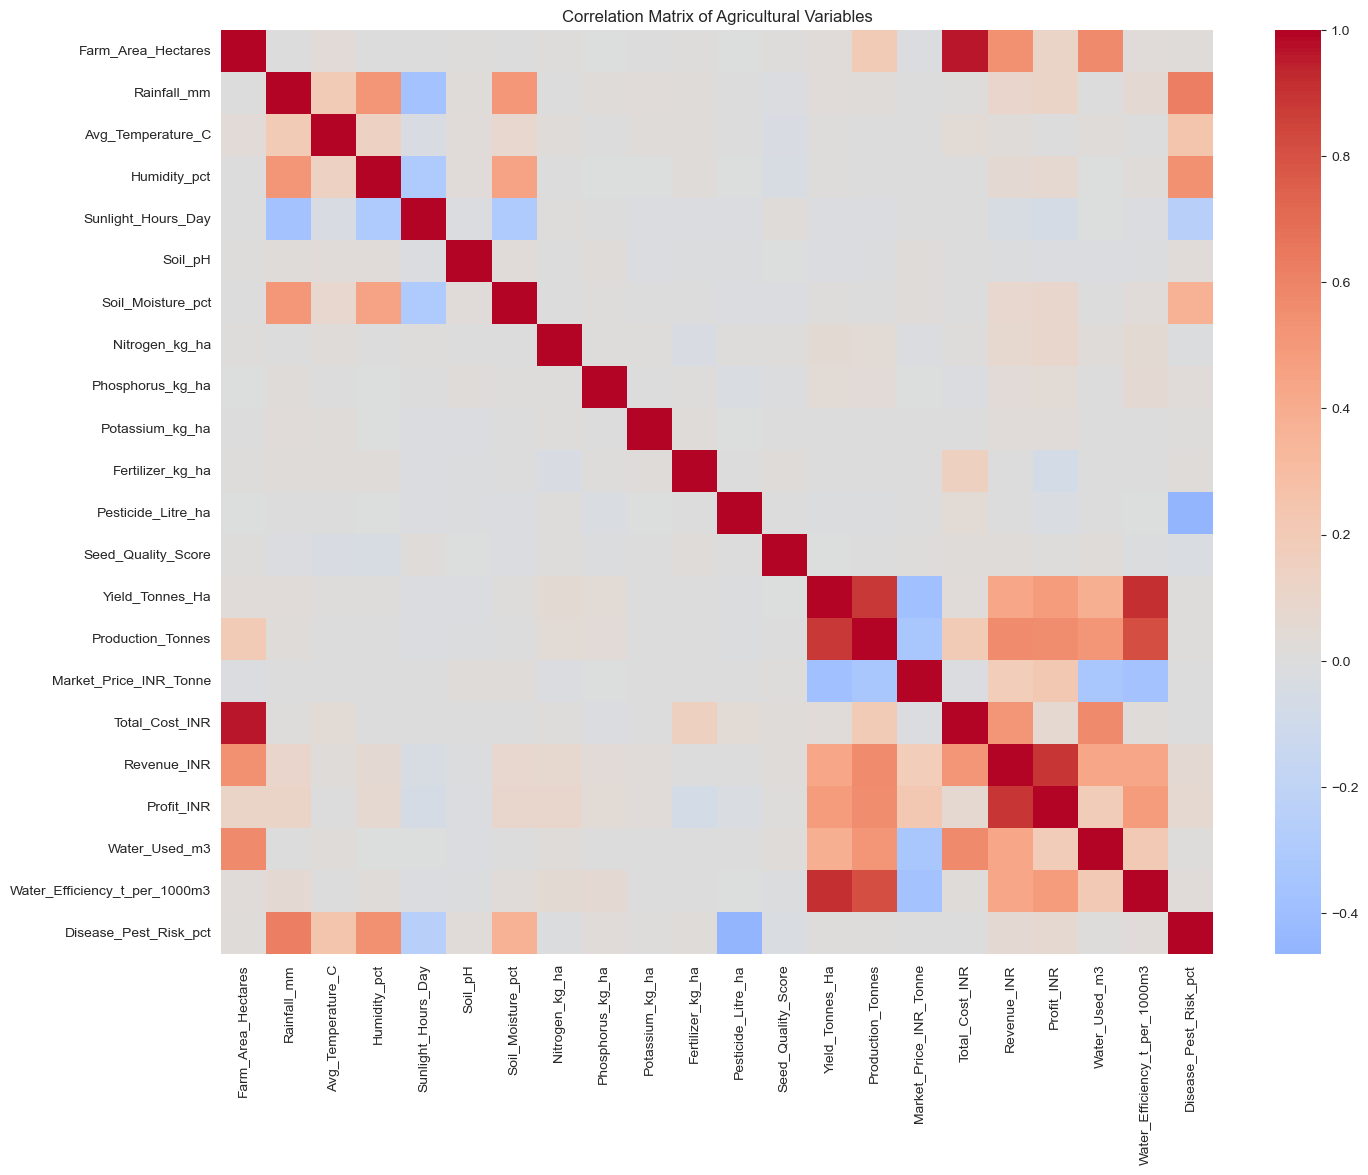

Strongest correlations with Yield:


,Correlation
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Market_Price_INR_Tonne,-0.38
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


Strongest correlations with Profit:


,Correlation
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Farm_Area_Hectares,0.12
Rainfall_mm,0.11
Soil_Moisture_pct,0.09
Nitrogen_kg_ha,0.09


In [25]:
#13 — Correlation analysis completed
print("Correlation analysis completed")

corr_cols = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH",
    "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha", "Production_Tonnes",
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
    "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Agricultural Variables")
plt.show()

# Strongest correlations with yield and profit
yield_corr = corr_matrix["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(key=abs, ascending=False)
profit_corr = corr_matrix["Profit_INR"].drop("Profit_INR").sort_values(key=abs, ascending=False)

print("Strongest correlations with Yield:")
display(yield_corr.head(10).to_frame("Correlation"))

print("Strongest correlations with Profit:")
display(profit_corr.head(10).to_frame("Correlation"))

Seasonal comparisons performed


Farm_Area_Hectares        Rainfall_mm        Avg_Temperature_C         \
                     mean median        mean median              mean median   
Season                                                                         
Kharif               7.94   8.18      849.20 853.10             28.45  28.50   
Rabi                 7.75   7.68      437.62 432.20             23.49  23.50   
Zaid                 8.09   8.09      304.65 288.20             31.04  31.00   

       Humidity_pct        Sunlight_Hours_Day        Soil_Moisture_pct         \
               mean median               mean median              mean median   
Season                                                                          
Kharif        71.81  71.90               6.79   6.80             31.15  31.10   
Rabi          57.89  58.10               7.59   7.60             24.07  24.00   
Zaid          52.01  52.35               8.18   8.20             19.28  19.10   

       Yield_Tonnes_Ha        Production_Tonnes        Market_Price_INR_Tonne  \
                  mean median              mean median                   mean   
Season                                                                          
Kharif            5.63   1.94             46.31  13.24              44,850.91   
Rabi              5.04   1.67             41.49  11.08              44,747.97   
Zaid              4.64   1.46             38.89   9.97              44,212.03   

                 Total_Cost_INR            Revenue_INR            Profit_INR  \
          median           mean     median        mean     median       mean   
Season                                                                         
Kharif 25,793.00     531,804.41 524,840.00  710,719.06 520,196.00 178,914.65   
Rabi   26,041.00     513,836.58 506,733.00  601,526.05 438,156.00  87,689.47   
Zaid   25,749.50     543,976.73 534,833.00  519,171.90 373,700.50 -24,804.82   

                  Water_Used_m3          Water_Efficiency_t_per_1000m3         \
           median          mean   median                          mean median   
Season                                                                          
Kharif  38,808.00      6,102.20 4,469.00                          5.89   3.28   
Rabi    -3,187.00      5,846.99 4,292.00                          5.19   2.74   
Zaid   -62,144.00      6,419.89 4,805.00                          4.41   2.30   

       Disease_Pest_Risk_pct         
                        mean median  
Season                               
Kharif                 54.47  54.50  
Rabi                   40.48  40.60  
Zaid                   38.22  37.90

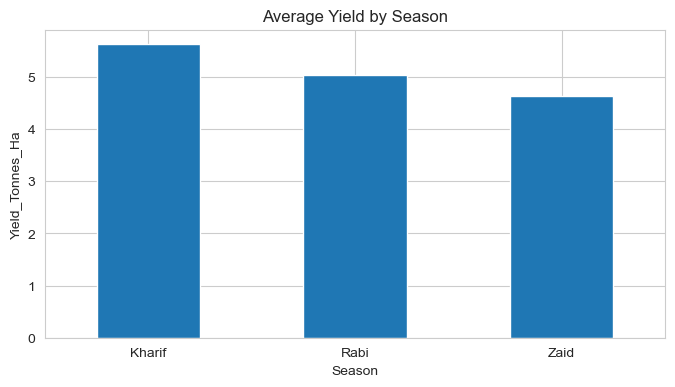

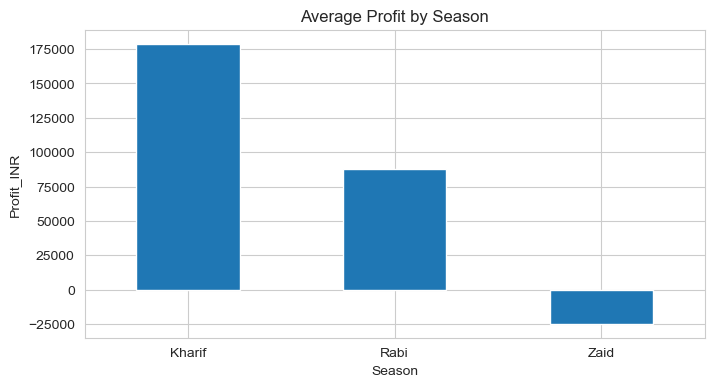

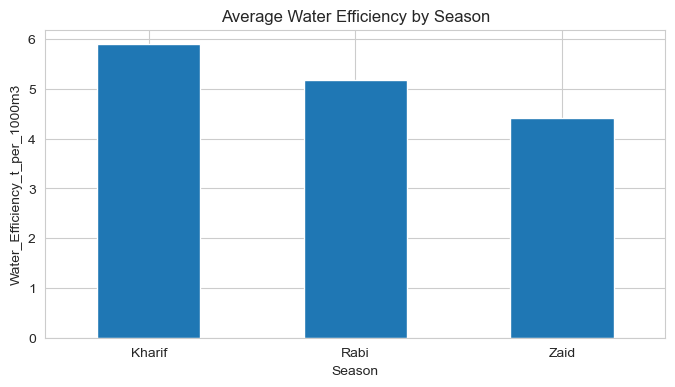

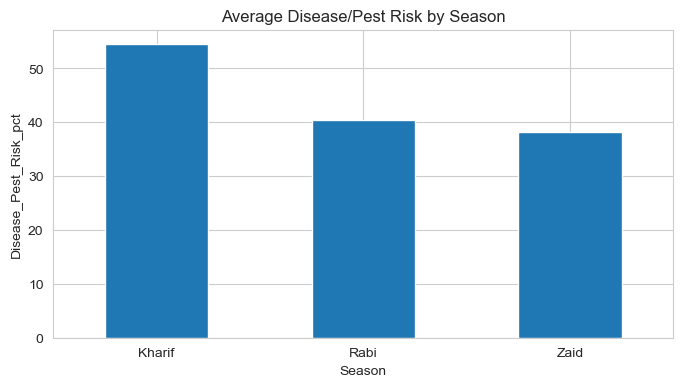

In [26]:
#14 — Seasonal comparisons performed
print("Seasonal comparisons performed")

season_metrics = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Sunlight_Hours_Day", "Soil_Moisture_pct",
    "Yield_Tonnes_Ha", "Production_Tonnes", "Market_Price_INR_Tonne",
    "Total_Cost_INR", "Revenue_INR", "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]
season_metrics = [c for c in season_metrics if c in df.columns]

season_summary = df.groupby("Season")[season_metrics].agg(["mean", "median"])
display(season_summary.round(2))

# Mean comparison charts
chart_metrics = [
    ("Yield_Tonnes_Ha", "Average Yield by Season"),
    ("Profit_INR", "Average Profit by Season"),
    ("Water_Efficiency_t_per_1000m3", "Average Water Efficiency by Season"),
    ("Disease_Pest_Risk_pct", "Average Disease/Pest Risk by Season")
]

for col, title in chart_metrics:
    plt.figure(figsize=(8, 4))
    values = df.groupby("Season")[col].mean().sort_values(ascending=False)
    values.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Season")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.show()


Irrigation effectiveness


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Water_Used
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00",6.27,"5,918.75"
Sprinkler,734,5.16,"91,121.08",4.67,"6,208.26"
Flood,1310,4.86,"73,354.02",3.44,"8,026.47"
Rainfed,1041,4.60,"79,050.37",7.56,"3,549.55"


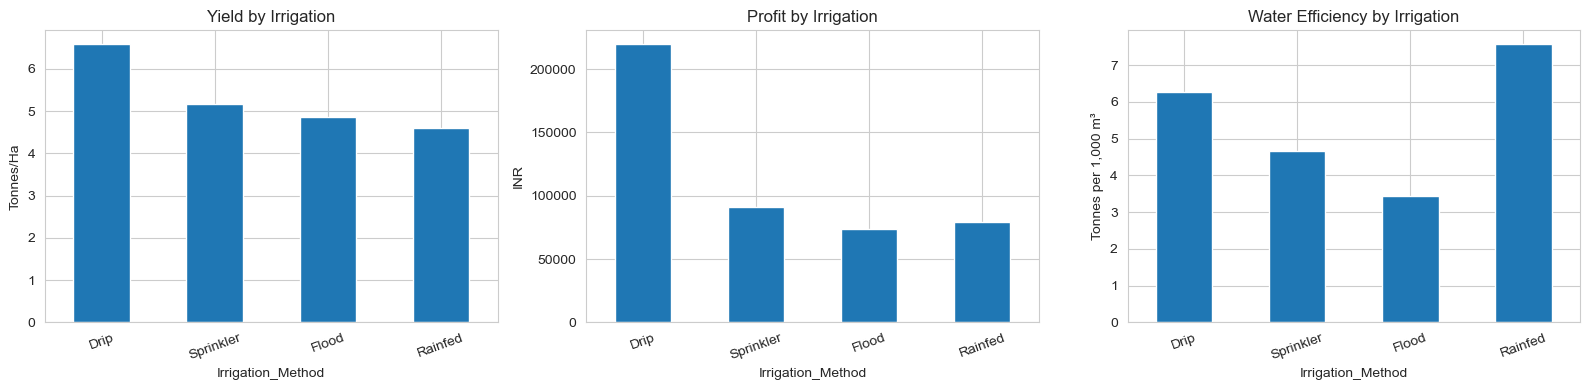

In [31]:
#15 — Which irrigation method provides the best combination of yield, profitability and water efficiency?
print("Irrigation effectiveness")

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean")
).sort_values("Avg_Yield", ascending=False)

display(irrigation_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
irrigation_summary["Avg_Yield"].plot(kind="bar", ax=axes[0], title="Yield by Irrigation")
axes[0].set_ylabel("Tonnes/Ha")
irrigation_summary["Avg_Profit"].plot(kind="bar", ax=axes[1], title="Profit by Irrigation")
axes[1].set_ylabel("INR")
irrigation_summary["Avg_Water_Efficiency"].plot(kind="bar", ax=axes[2], title="Water Efficiency by Irrigation")
axes[2].set_ylabel("Tonnes per 1,000 m³")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

 Season performance


,Crop,Season,Avg_Yield,Avg_Profit,Farms
18,Sugarcane,Kharif,53.46,"1,000,790.81",125
9,Maize,Kharif,2.97,"-39,332.67",234
15,Rice,Kharif,2.70,"-64,903.40",314
21,Wheat,Kharif,2.25,"-105,871.87",292
0,Chilli,Kharif,1.73,"954,380.42",185
6,Groundnut,Kharif,1.48,"108,265.44",193
3,Cotton,Kharif,1.37,"216,999.55",215
12,Pulses,Kharif,1.04,"43,338.90",221
19,Sugarcane,Rabi,43.29,"731,612.86",129
10,Maize,Rabi,2.60,"-89,133.40",233


Highest-yielding crop in each season:


,Crop,Season,Avg_Yield,Avg_Profit,Farms
18,Sugarcane,Kharif,53.46,"1,000,790.81",125
19,Sugarcane,Rabi,43.29,"731,612.86",129
20,Sugarcane,Zaid,38.42,"583,635.80",51


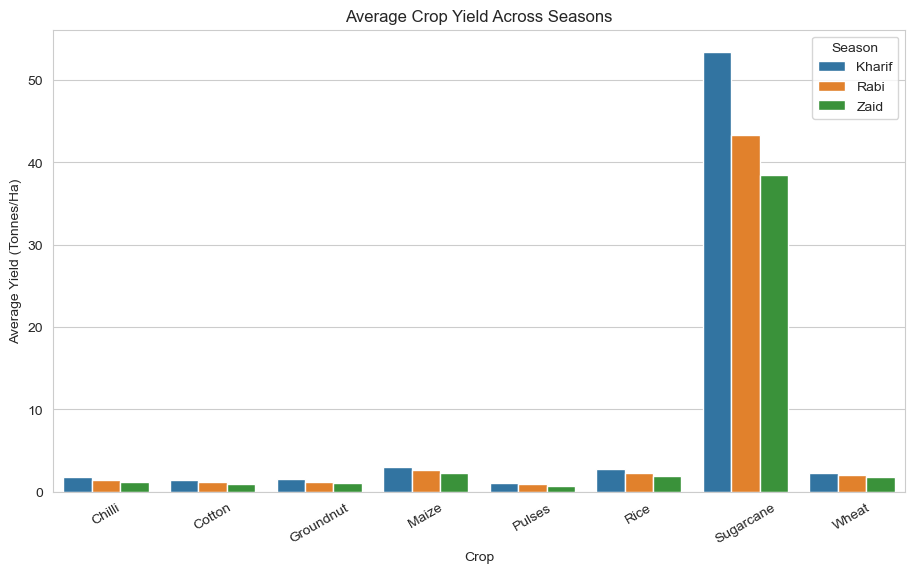

In [32]:
#16 — Does the best-performing crop remain the same across all seasons?
print(" Season performance")

crop_season = df.groupby(["Crop", "Season"]).agg(
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Farms=("Farm_ID", "count")
).reset_index()

display(crop_season.sort_values(["Season", "Avg_Yield"], ascending=[True, False]).round(2))

# Best crop in each season
best_crop_by_season = crop_season.loc[
    crop_season.groupby("Season")["Avg_Yield"].idxmax()
].sort_values("Season")

print("Highest-yielding crop in each season:")
display(best_crop_by_season.round(2))

plt.figure(figsize=(11, 6))
sns.barplot(data=crop_season, x="Crop", y="Avg_Yield", hue="Season")
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.show()


Profitability vs water efficiency


,Farm_Count,Percentage
Performance_Quadrant,,
Lower Profit + Lower Water Efficiency,1326,33.15
High Profit + High Water Efficiency,1326,33.15
Lower Profit + High Water Efficiency,674,16.85
High Profit + Lower Water Efficiency,674,16.85


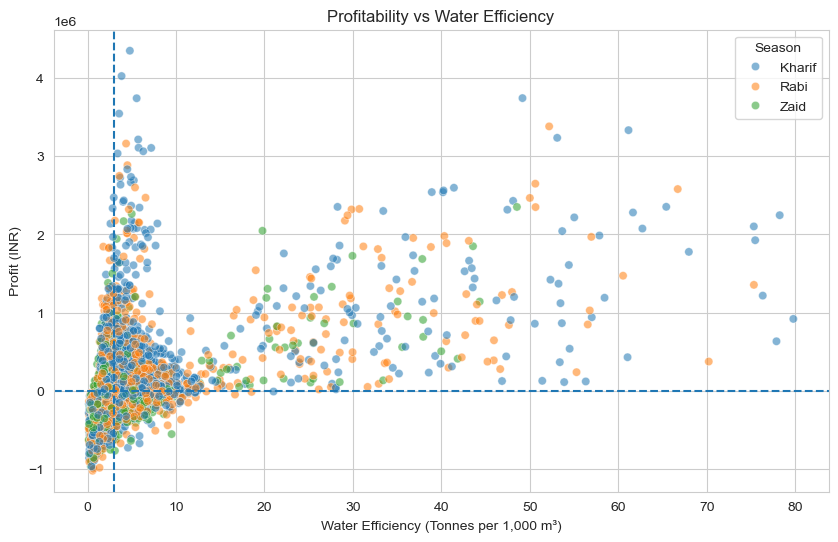

In [33]:
#17 — Which farms combine stronger economic performance with efficient water use?
print("Profitability vs water efficiency")

# Use median values to define four performance quadrants
profit_median = df["Profit_INR"].median()
water_eff_median = df["Water_Efficiency_t_per_1000m3"].median()

df["Performance_Quadrant"] = np.select(
    [
        (df["Profit_INR"] >= profit_median) & (df["Water_Efficiency_t_per_1000m3"] >= water_eff_median),
        (df["Profit_INR"] >= profit_median) & (df["Water_Efficiency_t_per_1000m3"] < water_eff_median),
        (df["Profit_INR"] < profit_median) & (df["Water_Efficiency_t_per_1000m3"] >= water_eff_median)
    ],
    [
        "High Profit + High Water Efficiency",
        "High Profit + Lower Water Efficiency",
        "Lower Profit + High Water Efficiency"
    ],
    default="Lower Profit + Lower Water Efficiency"
)

quadrant_summary = df["Performance_Quadrant"].value_counts().to_frame("Farm_Count")
quadrant_summary["Percentage"] = quadrant_summary["Farm_Count"] / len(df) * 100
display(quadrant_summary.round(2))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Water_Efficiency_t_per_1000m3",
    y="Profit_INR",
    hue="Season",
    alpha=0.55
)
plt.axvline(water_eff_median, linestyle="--")
plt.axhline(profit_median, linestyle="--")
plt.title("Profitability vs Water Efficiency")
plt.xlabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.ylabel("Profit (INR)")
plt.show()


In [35]:
#18 — Meaningful insights documented
print("Meaningful insights documented")

# Core seasonal means
season_mean = df.groupby("Season").agg(
    Yield=("Yield_Tonnes_Ha", "mean"),
    Profit=("Profit_INR", "mean"),
    Rainfall=("Rainfall_mm", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Water_Used=("Water_Used_m3", "mean")
)

best_yield_season = season_mean["Yield"].idxmax()
lowest_yield_season = season_mean["Yield"].idxmin()
best_profit_season = season_mean["Profit"].idxmax()
best_water_season = season_mean["Water_Efficiency"].idxmax()
lowest_risk_season = season_mean["Disease_Risk"].idxmin()

best_irrigation = irrigation_summary["Avg_Yield"].idxmax()
best_irrigation_profit = irrigation_summary["Avg_Profit"].idxmax()
best_irrigation_water = irrigation_summary["Avg_Water_Efficiency"].idxmax()

best_crop_overall = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax()
lowest_crop_overall = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmin()

yield_profit_corr = df["Yield_Tonnes_Ha"].corr(df["Profit_INR"])
rain_yield_corr = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])

# Season gaps
yield_gap = season_mean["Yield"].max() - season_mean["Yield"].min()
profit_gap = season_mean["Profit"].max() - season_mean["Profit"].min()

insights = [
    f"1. {best_yield_season} has the highest average yield at {season_mean.loc[best_yield_season, 'Yield']:.2f} tonnes/ha, while {lowest_yield_season} has the lowest at {season_mean.loc[lowest_yield_season, 'Yield']:.2f} tonnes/ha.",
    f"2. The difference between the highest- and lowest-yield seasons is {yield_gap:.2f} tonnes/ha, showing a measurable seasonal performance gap.",
    f"3. {best_profit_season} has the highest average profit at ₹{season_mean.loc[best_profit_season, 'Profit']:,.0f} per farm record.",
    f"4. {best_water_season} has the highest average water efficiency at {season_mean.loc[best_water_season, 'Water_Efficiency']:.2f} tonnes per 1,000 m³.",
    f"5. {lowest_risk_season} has the lowest average disease/pest risk at {season_mean.loc[lowest_risk_season, 'Disease_Risk']:.2f}%.",
    f"6. {best_irrigation} has the highest average yield among irrigation methods at {irrigation_summary.loc[best_irrigation, 'Avg_Yield']:.2f} tonnes/ha.",
    f"7. {best_irrigation_profit} has the highest average profit among irrigation methods at ₹{irrigation_summary.loc[best_irrigation_profit, 'Avg_Profit']:,.0f}.",
    f"8. {best_irrigation_water} has the highest average water efficiency among irrigation methods at {irrigation_summary.loc[best_irrigation_water, 'Avg_Water_Efficiency']:.2f} tonnes per 1,000 m³.",
    f"9. {best_crop_overall} has the highest average yield across all crop records at {df.groupby('Crop')['Yield_Tonnes_Ha'].mean().max():.2f} tonnes/ha; {lowest_crop_overall} has the lowest at {df.groupby('Crop')['Yield_Tonnes_Ha'].mean().min():.2f} tonnes/ha.",
    f"10. The correlation between yield and profit is {yield_profit_corr:.2f}; this describes association in the dataset and should not be interpreted as proof of causation.",
    f"11. The correlation between rainfall and yield is {rain_yield_corr:.2f}; rainfall alone does not explain all yield variation.",
    f"12. The dataset contains {df['Season'].nunique()} seasons and {df['Crop'].nunique()} crops, allowing seasonal and crop-level comparisons."
]

for insight in insights:
    print(insight)

Meaningful insights documented
1. Kharif has the highest average yield at 5.63 tonnes/ha, while Zaid has the lowest at 4.64 tonnes/ha.
2. The difference between the highest- and lowest-yield seasons is 0.99 tonnes/ha, showing a measurable seasonal performance gap.
3. Kharif has the highest average profit at ₹178,915 per farm record.
4. Kharif has the highest average water efficiency at 5.89 tonnes per 1,000 m³.
5. Zaid has the lowest average disease/pest risk at 38.22%.
6. Drip has the highest average yield among irrigation methods at 6.58 tonnes/ha.
7. Drip has the highest average profit among irrigation methods at ₹219,626.
8. Rainfed has the highest average water efficiency among irrigation methods at 7.56 tonnes per 1,000 m³.
9. Sugarcane has the highest average yield across all crop records at 46.64 tonnes/ha; Pulses has the lowest at 0.92 tonnes/ha.
10. The correlation between yield and profit is 0.49; this describes association in the dataset and should not be interpreted as pro